In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import shap
from sklearn.cluster import KMeans

In [23]:
# Wczytanie danych
df = pd.read_csv("Tourists_lakes_Nature.csv")

# Czyszczenie
df = df.dropna()

# Target
target = "Tourism"

X = df.drop(columns=[target])
y = df[target]

# Podział
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

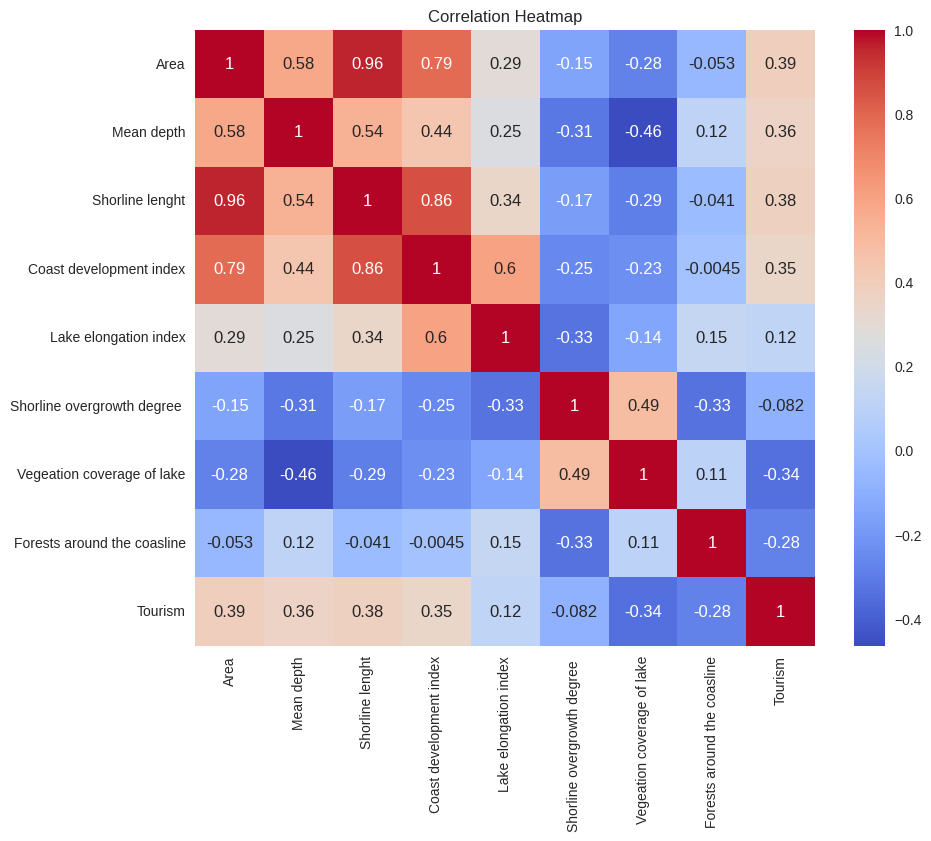

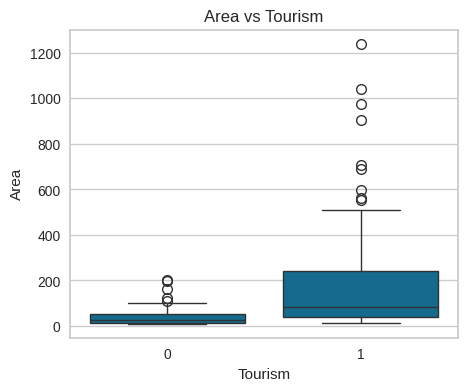

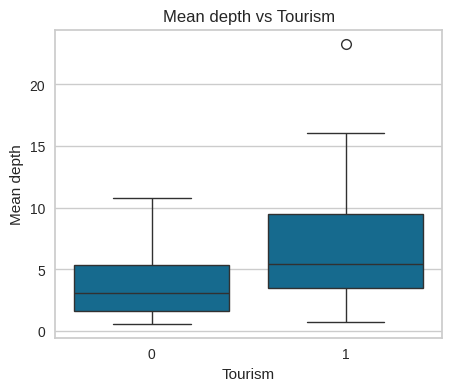

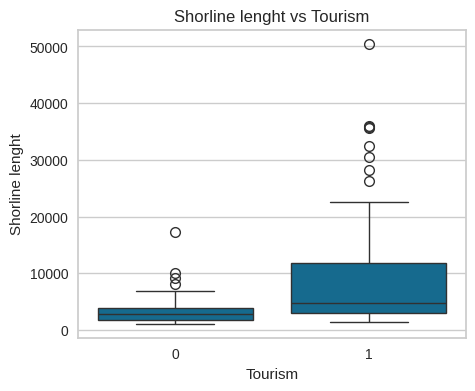

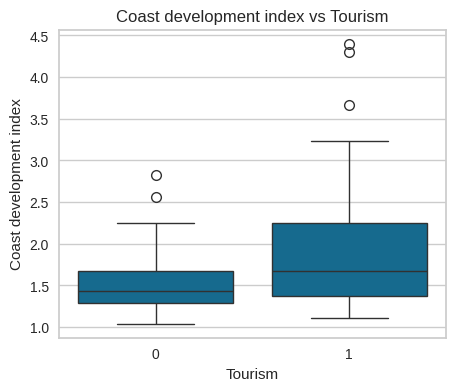

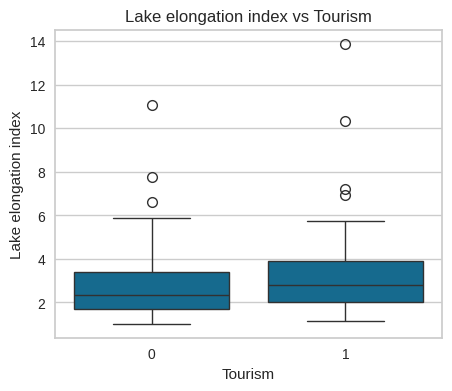

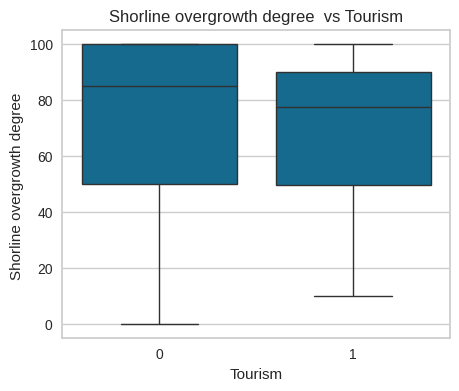

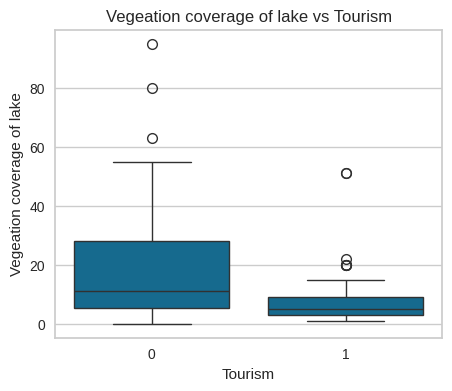

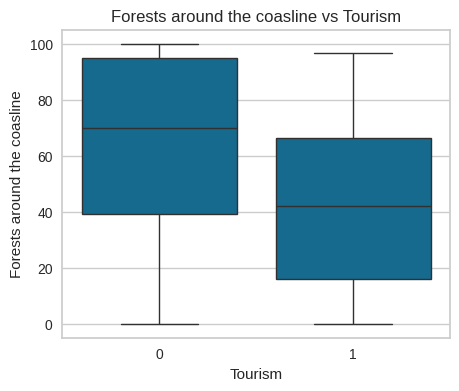

In [24]:
# Heatmapa korelacji
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxploty
for col in X.columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs Tourism")
    plt.show()

In [25]:
results = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("Confusion matrix:\n", cm)
    print(classification_report(y_test, y_pred, zero_division=0))

    results[name] = acc

# Modele
dummy = DummyClassifier()
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gbm = GradientBoostingClassifier(n_estimators=200)
xgb = XGBClassifier(max_depth=10, learning_rate=0.001, n_estimators=1000, eval_metric="logloss")

evaluate_model("Dummy", dummy)
evaluate_model("Random Forest", rf)
evaluate_model("GBM", gbm)
evaluate_model("XGBoost", xgb)


=== Dummy ===
Accuracy: 0.4318181818181818
Confusion matrix:
 [[19  0]
 [25  0]]
              precision    recall  f1-score   support

           0       0.43      1.00      0.60        19
           1       0.00      0.00      0.00        25

    accuracy                           0.43        44
   macro avg       0.22      0.50      0.30        44
weighted avg       0.19      0.43      0.26        44


=== Random Forest ===
Accuracy: 0.6363636363636364
Confusion matrix:
 [[12  7]
 [ 9 16]]
              precision    recall  f1-score   support

           0       0.57      0.63      0.60        19
           1       0.70      0.64      0.67        25

    accuracy                           0.64        44
   macro avg       0.63      0.64      0.63        44
weighted avg       0.64      0.64      0.64        44


=== GBM ===
Accuracy: 0.6136363636363636
Confusion matrix:
 [[11  8]
 [ 9 16]]
              precision    recall  f1-score   support

           0       0.55      0.58      

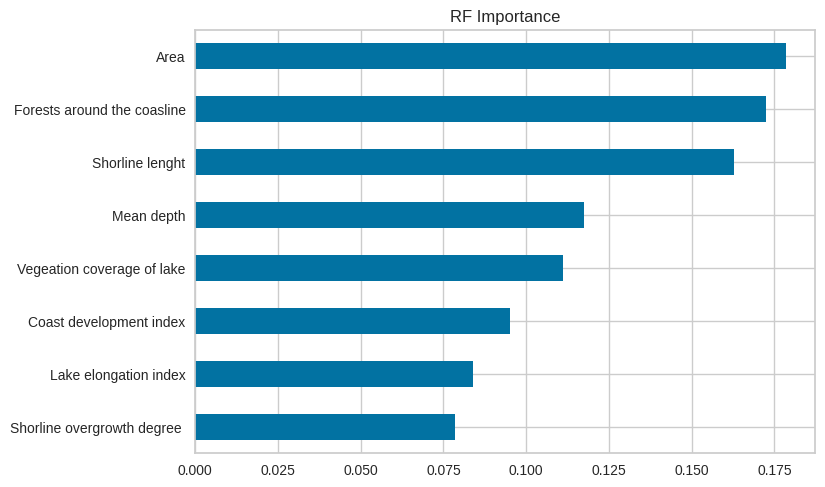

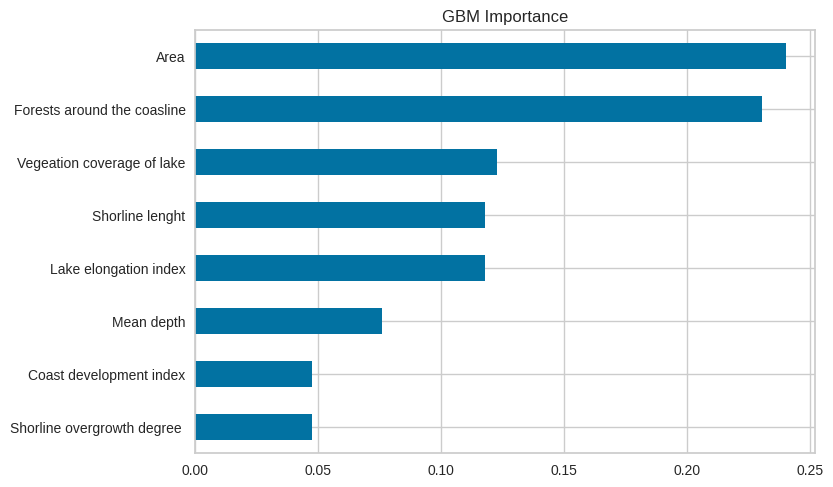

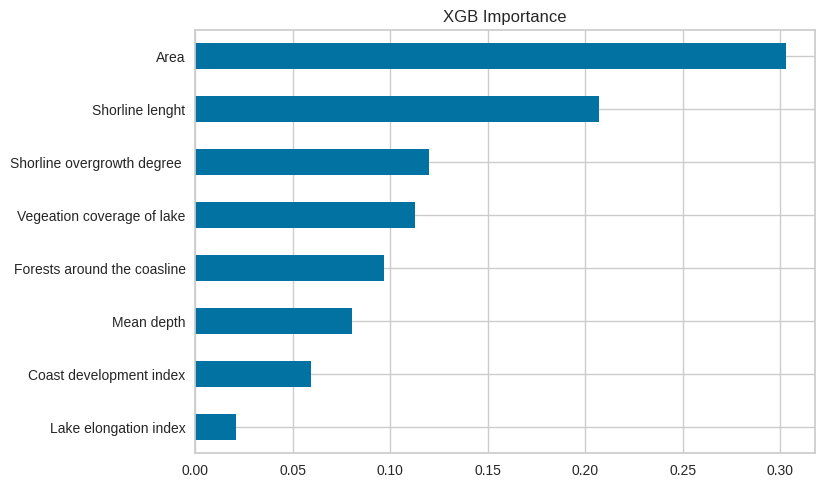

In [26]:
# RF
rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
rf_imp.sort_values().plot(kind="barh", title="RF Importance")
plt.show()

# GBM
gbm_imp = pd.Series(gbm.feature_importances_, index=X.columns)
gbm_imp.sort_values().plot(kind="barh", title="GBM Importance")
plt.show()

# XGB
xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_imp.sort_values().plot(kind="barh", title="XGB Importance")
plt.show()

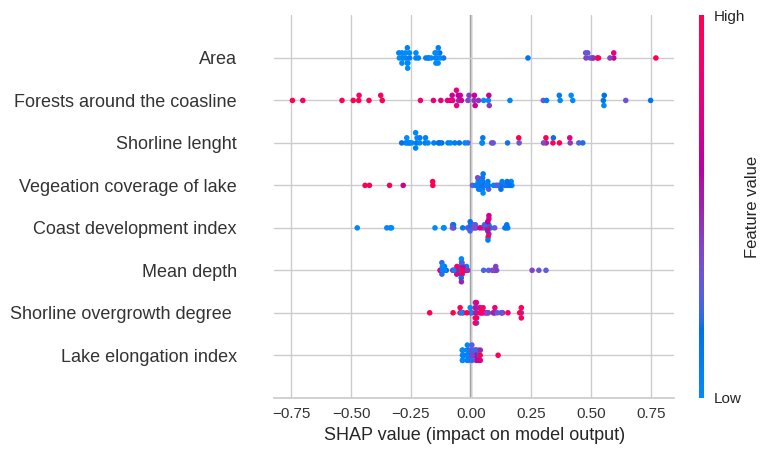

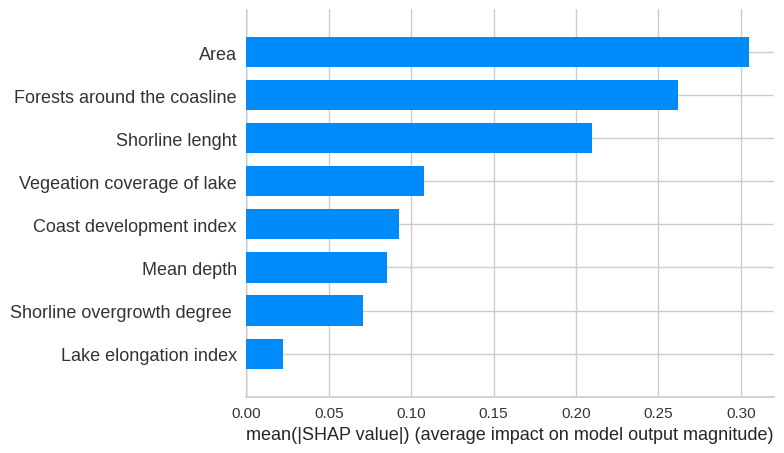

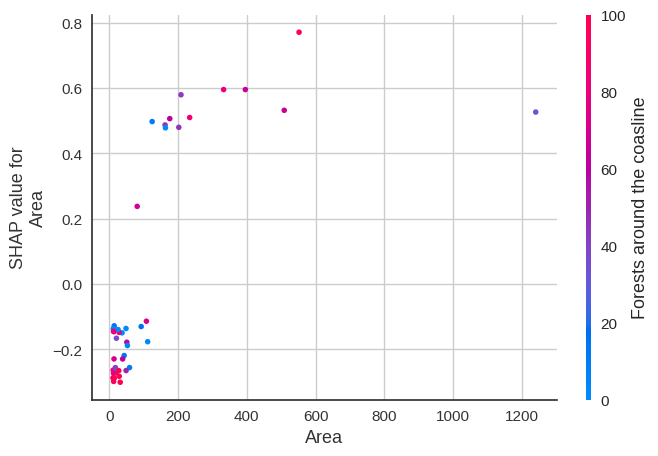

In [27]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot (globalny wpływ)
shap.summary_plot(shap_values, X_test)

# Bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Dependence (interakcje)
shap.dependence_plot(X.columns[0], shap_values, X_test)

In [28]:
# SHAP importance
shap_imp = pd.DataFrame({
    "feature": X.columns,
    "SHAP": np.abs(shap_values).mean(axis=0)
}).set_index("feature")

ranking_df = pd.DataFrame({
    "RF": rf_imp,
    "GBM": gbm_imp,
    "XGB": xgb_imp,
}).join(shap_imp)

print("\n=== PORÓWNANIE RANKINGÓW ===")
print(ranking_df.sort_values("SHAP", ascending=False))


=== PORÓWNANIE RANKINGÓW ===
                                   RF       GBM       XGB      SHAP
Area                         0.178423  0.240191  0.302859  0.304940
Forests around the coasline  0.172525  0.230372  0.097065  0.261683
Shorline lenght              0.162780  0.117928  0.207331  0.209780
Vegeation coverage of lake   0.111210  0.122676  0.112614  0.107837
Coast development index      0.095130  0.047636  0.059155  0.092586
Mean depth                   0.117333  0.075830  0.080379  0.085144
Shorline overgrowth degree   0.078535  0.047503  0.119681  0.070615
Lake elongation index        0.084065  0.117864  0.020917  0.022281


In [29]:
# wybór próbek
touristic = X_test[y_test == 1].head(2)
non_touristic = X_test[y_test == 0].head(2)

samples = pd.concat([touristic, non_touristic])

shap.initjs()

for i in range(4):
    print(f"\n--- Jezioro {i} ---")
    display(
        shap.force_plot(
            explainer.expected_value,
            shap_values[X_test.index.get_loc(samples.index[i])],
            samples.iloc[i]
        )
    )


--- Jezioro 0 ---



--- Jezioro 1 ---



--- Jezioro 2 ---



--- Jezioro 3 ---



=== ŚREDNIE CECH W KLASTRACH ===
               Area  Mean depth  Shorline lenght  Coast development index  \
cluster                                                                     
0         20.911111    4.816667      2377.277778                 1.446667   
1        337.007692    7.769231     14542.769231                 2.356154   
2         52.046154    4.853846      3773.692308                 1.542308   

         Lake elongation index  Shorline overgrowth degree   \
cluster                                                       
0                     2.537769                    67.277778   
1                     4.511544                    67.615385   
2                     2.569442                    80.230769   

         Vegeation coverage of lake  Forests around the coasline   Tourism  
cluster                                                                     
0                         21.555556                    79.322190  0.333333  
1                          6.6923

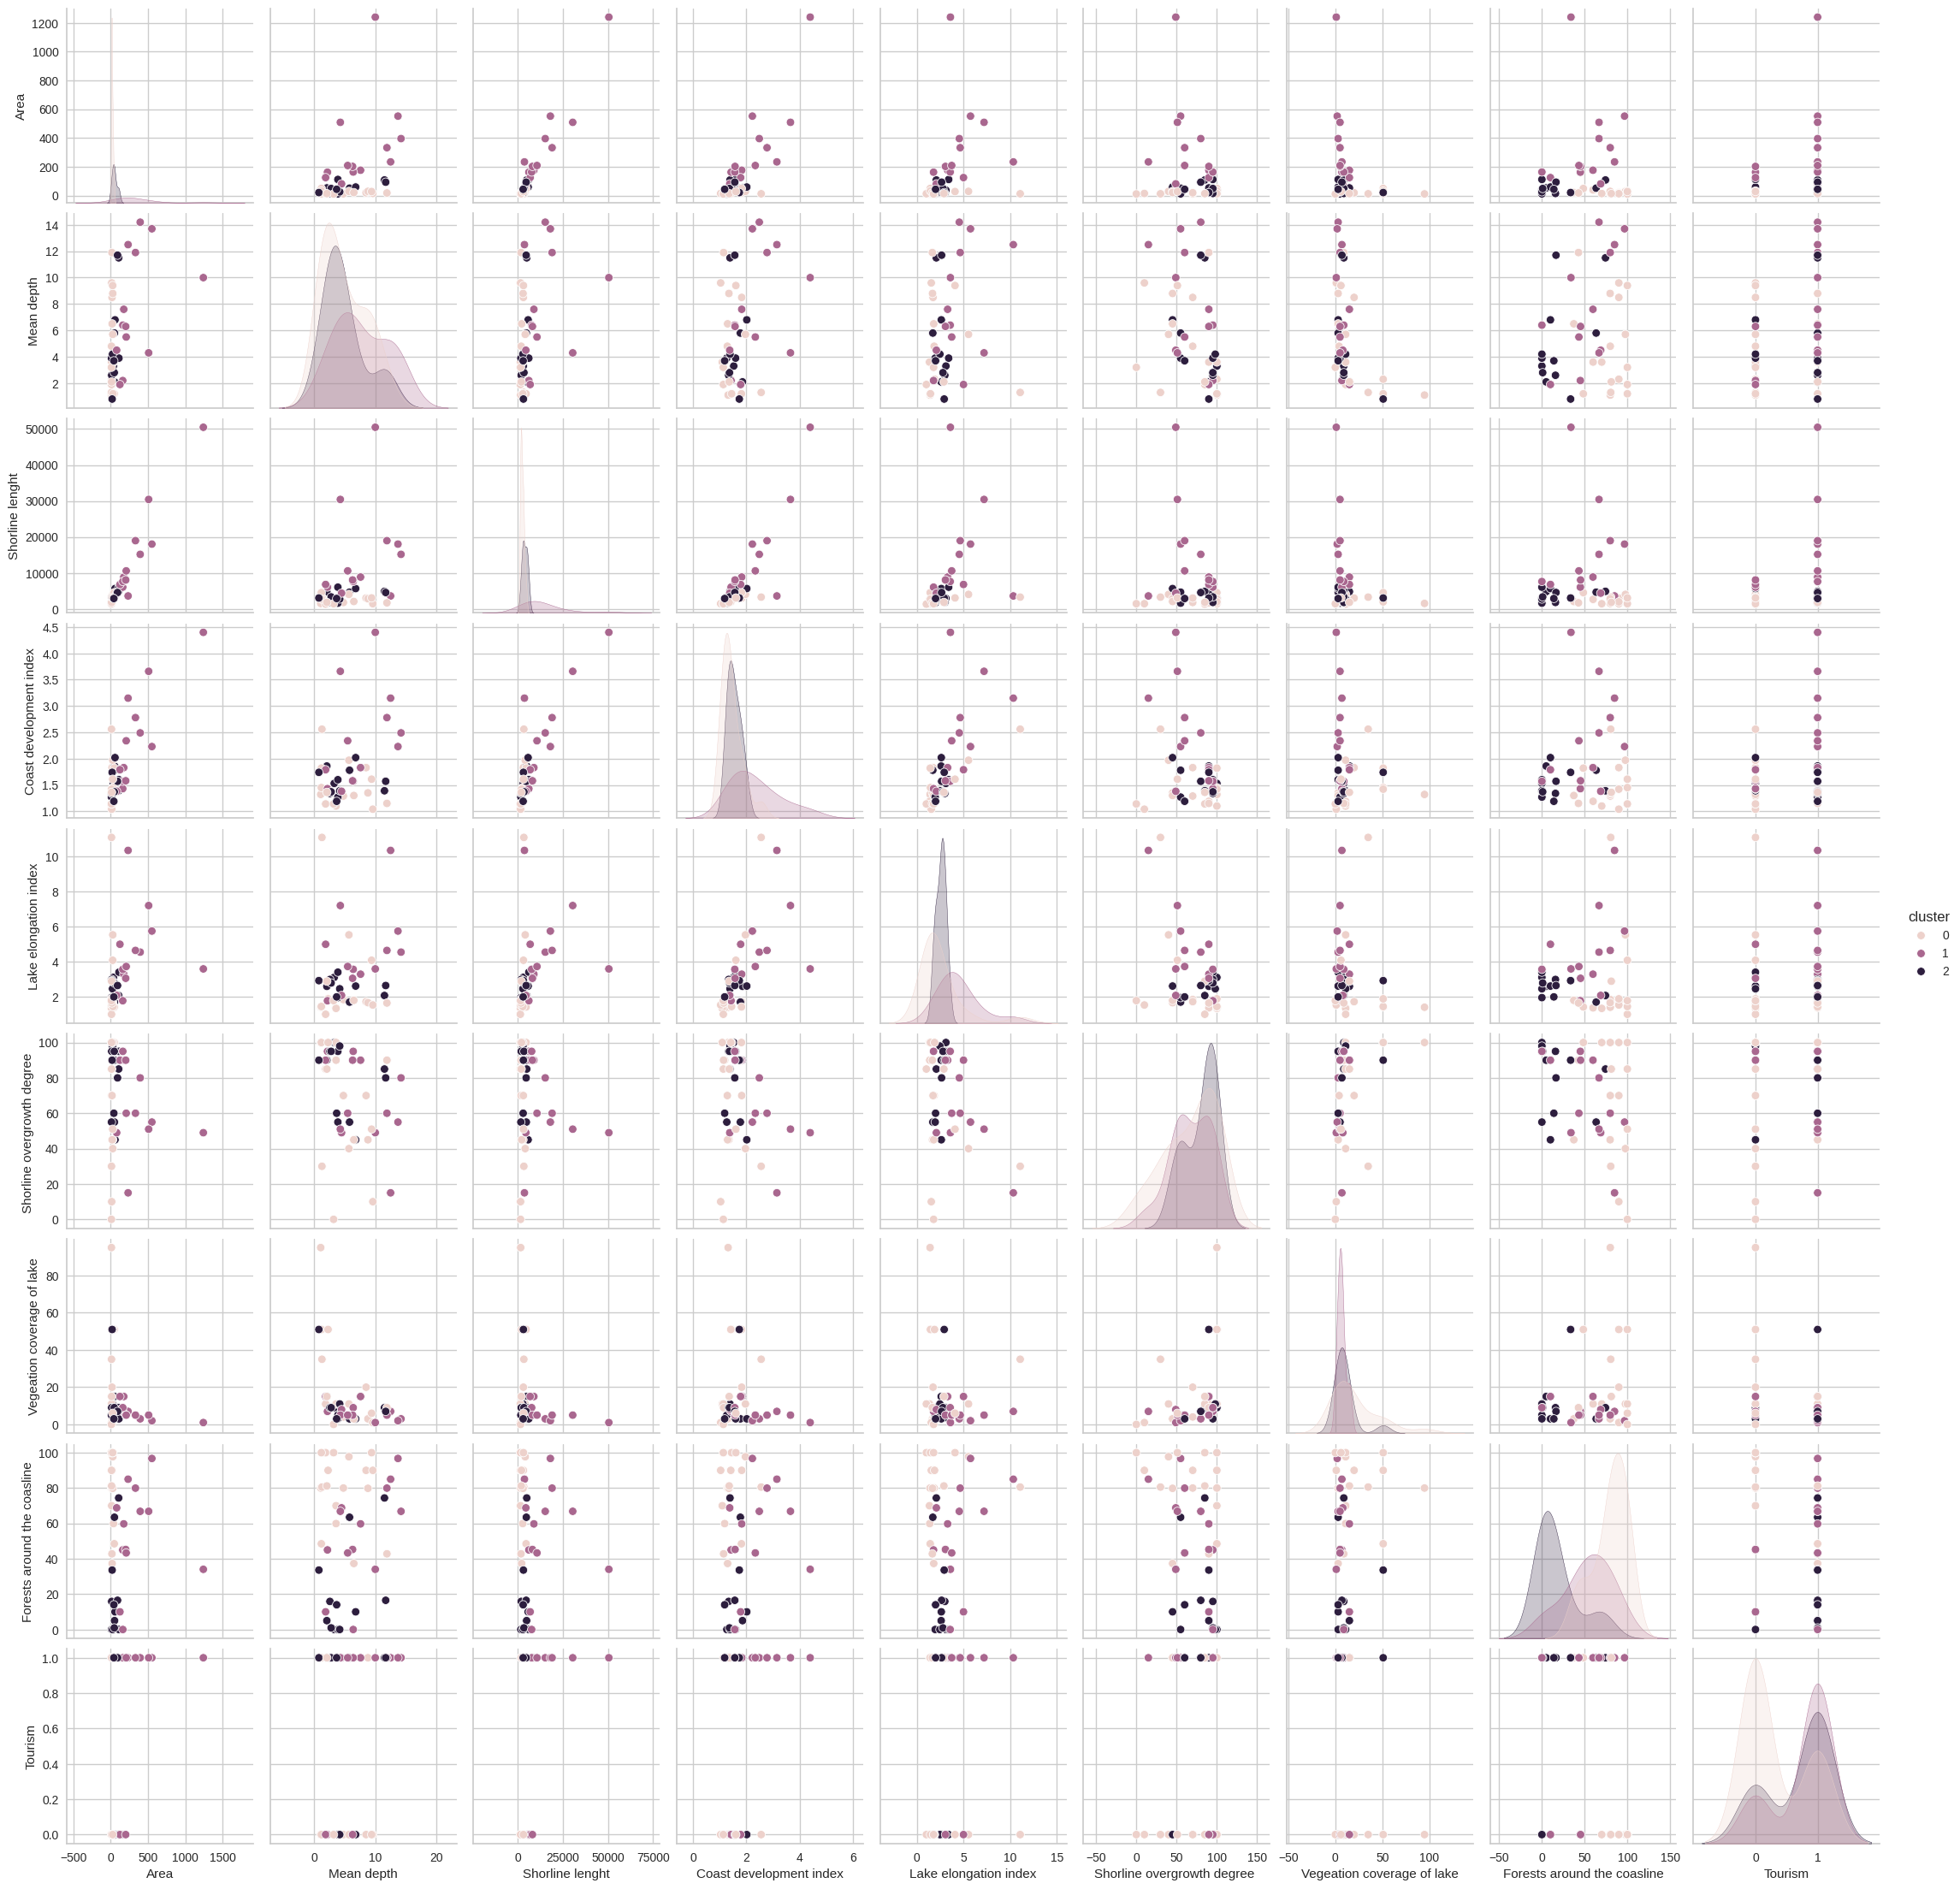

In [30]:
# klastrowanie na SHAP
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(shap_values)

X_test_clustered = X_test.copy()
X_test_clustered["cluster"] = clusters
X_test_clustered["Tourism"] = y_test.values

print("\n=== ŚREDNIE CECH W KLASTRACH ===")
print(X_test_clustered.groupby("cluster").mean())

# wizualizacja klastrów
sns.pairplot(X_test_clustered, hue="cluster")
plt.show()

1. Najważniejsze cechy (zgodne między modelami):
   - np. powierzchnia jeziora (Area)
   - długość linii brzegowej
   - indeks rozwoju linii brzegowej

2. SHAP ujawnia dodatkowo:
   - wpływ roślinności
   - wpływ lasów wokół jeziora

3. Różnice:
   - RF i GBM → bardziej globalne znaczenie cech
   - XGB → uwzględnia interakcje
   - SHAP → pokazuje rzeczywisty wpływ na predykcję

4. Jeziora turystyczne:
   - większe
   - bardziej rozwinięta linia brzegowa
   - umiarkowana roślinność

5. Jeziora nieturystyczne:
   - mniejsze
   - silnie zarośnięte
   - mniej dostępne

6. Klastery:
   - grupa 1: jeziora turystyczne
   - grupa 2: nieturystyczne
   - grupa 3: mieszane